# Sources of Numerical Errors

Every numerical computation introduces some error. Understanding *where* errors come from — and how to measure, predict, and control them — is the foundation of reliable scientific computing.

## Learning Objectives

By the end of this session, you will be able to:
- Define and compute **true error**, **true relative error**, and **approximate relative error**
- Apply the **Scarborough criterion** to decide when an iterative method has converged
- Explain **truncation error** using Taylor series and quantify its order of accuracy
- Explain **roundoff error** using IEEE 754 floating-point representation and machine epsilon
- Demonstrate how **catastrophic cancellation** amplifies roundoff
- Derive **forward**, **backward**, and **central** finite-difference approximations and compare their accuracy
- Show the **trade-off** between truncation error and roundoff as step size changes

## Session Outline

| # | Topic | 
|---|-------| 
| 1 | Error Definitions & Metrics | 
| 2 | Truncation Error & Taylor Series | 
| 3 | Roundoff Error & Floating-Point Arithmetic | 
| 4 | Finite Differences & Combined Error Analysis |

## Two Fundamental Sources of Numerical Error

| Source | Cause | Controlled by |
|--------|-------|---------------|
| **Truncation error** | Replacing an infinite/exact process with a finite approximation | Number of terms, step size |
| **Roundoff error** | Finite precision of floating-point representation | Hardware, data type choice |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

---
## 1. Error Definitions and Metrics

### 1.1 Absolute and Relative Errors

Let $x_{\text{true}}$ be the exact value and $x_{\text{approx}}$ be a numerical approximation.

| Quantity | Formula | Unit |
|----------|---------|------|
| **True (absolute) error** | $E_t = x_{\text{true}} - x_{\text{approx}}$ | same as $x$ |
| **True relative error** | $\varepsilon_t =  \frac{\|E_t\|}{\|x_{\text{true}}\|}\times 100\% $ | % |
| **Approximate relative error** | $\varepsilon_a = \frac{\| x_{\text{new}} - x_{\text{prev}} \|}{\|x_{\text{new}}\|}\times 100\% $ | % |

**Why use relative error?** Absolute error alone is misleading: an error of 1 metre is catastrophic when measuring a microchip, but negligible when measuring the distance to the Moon. Relative error normalises by the scale of the quantity.

### 1.2 The Scarborough Criterion

In practice, the true value is unknown. The **Scarborough criterion** (1966) tells us how small $\varepsilon_a$ must be to guarantee $n$ correct significant figures in the result:

$$\varepsilon_a < \varepsilon_s = (0.5 \times 10^{2-n})\%$$

For example, to achieve **3 significant figures**, we need $\varepsilon_a < 0.05\%$.

In [2]:
# Scarborough stopping criterion
scarborough = lambda n: 0.5 * 10**(2 - n)

print('Significant figures | Stopping criterion (es)')
print('-' * 45)
for n in range(1, 8):
    print(f'         {n}          |   {scarborough(n):.6f} %')

Significant figures | Stopping criterion (es)
---------------------------------------------
         1          |   5.000000 %
         2          |   0.500000 %
         3          |   0.050000 %
         4          |   0.005000 %
         5          |   0.000500 %
         6          |   0.000050 %
         7          |   0.000005 %


### 1.3 Example: Approximating $\sqrt{2}$

The Babylonian (Heron's) method approximates $\sqrt{x}$ by iteration:

$$x_{n+1} = \frac{1}{2}\left(x_n + \frac{x}{x_n}\right)$$

Starting from $x_0 = 1.0$, let us apply this to $\sqrt{2}$ and track errors.

In [4]:
x_true = math.sqrt(2)   # reference value
x = 1.0                 # initial guess
target = 2.0            # we want sqrt(2)

print(f'{"Iter":>4}  {"Approx":>18}  {"True Rel Err (%)":>18}  {"Approx Rel Err (%)":>20}')
print('-' * 68)

for i in range(6):
    x_prev = x
    x = 0.5 * (x + target / x)      # Babylonian update
    et = abs(x_true - x) / x_true * 100
    ea = abs(x - x_prev) / abs(x)   * 100 if i > 0 else float('nan')
    print(f'{i+1:>4}  {x:>18.15f}  {et:>18.10f}  {ea:>20.10f}')

Iter              Approx    True Rel Err (%)    Approx Rel Err (%)
--------------------------------------------------------------------
   1   1.500000000000000        6.0660171780                   nan
   2   1.416666666666667        0.1734606681          5.8823529412
   3   1.414215686274510        0.0001501825          0.1733102253
   4   1.414213562374690        0.0000000001          0.0001501824
   5   1.414213562373095        0.0000000000          0.0000000001
   6   1.414213562373095        0.0000000000          0.0000000000


> **Observe:** True relative error roughly *squares* each iteration (quadratic convergence). Once $\varepsilon_a < \varepsilon_s$ for your desired number of significant figures, the iteration is complete.

---
## 2. Truncation Error & Taylor Series

### 2.1 Taylor Series Theorem

Any smooth function $f(x)$ can be written as an **infinite** power series expanded around a point $a$:

$$f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots$$

Keeping only the first $n+1$ terms introduces a **truncation error** $R_n$ (the remainder):

$$R_n = \frac{f^{(n+1)}(\xi)}{(n+1)!}(x-a)^{n+1}, \quad \xi \in (a, x)$$

The notation $O(h^{n+1})$ ("order $h^{n+1}$") means the error scales like $h^{n+1}$ as $h = x - a \to 0$.

| Terms kept | Order of truncation error |
|------------|---------------------------|
| 1 (constant) | $O(h)$ |
| 2 (linear) | $O(h^2)$ |
| 3 (quadratic) | $O(h^3)$ |
| $n+1$ | $O(h^{n+1})$ |

When $a = 0$ the series is called a **Maclaurin series**.

### 2.2 Maclaurin Series for $e^x$

The exponential function has the especially clean Maclaurin expansion:

$$e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots = \sum_{k=0}^{\infty} \frac{x^k}{k!}$$

We will approximate $e^{0.5}$ by adding terms one at a time and watch the error decrease.

In [5]:
# True value
x = 0.5
f_true = np.exp(x)
print(f'True value e^{x} = {f_true:.15f}')

True value e^0.5 = 1.648721270700128


In [6]:
# Build approximations term by term  (k=0,1,2,...,5 → 6 terms)
# f_approx[k] = sum_{i=0}^{k} x^i / i!

# --- COMPLETE: fill in the missing partial sums ---
f_approx = np.zeros(6)
f_approx[0] = 1                               # k=0: just the constant term
f_approx[1] = f_approx[0] + x                # k=1: + x
f_approx[2] = f_approx[1] + x**2 / math.factorial(2)   # k=2: + x^2/2!
f_approx[3] =                                # k=3: + x^3/3!
f_approx[4] =                                # k=4: + x^4/4!
f_approx[5] =                                # k=5: + x^5/5!
# --- COMPLETE ---

print(f'{"Terms":>6}  {"Approximation":>20}  {"True Rel Err (%)":>18}')
print('-' * 50)
for k in range(6):
    et = abs(f_true - f_approx[k]) / f_true * 100
    print(f'{k+1:>6}  {f_approx[k]:>20.15f}  {et:>18.10f}')

SyntaxError: invalid syntax (1289295811.py, line 9)

<!-- SOLUTION
f_approx[3] = f_approx[2] + x**3 / math.factorial(3)
f_approx[4] = f_approx[3] + x**4 / math.factorial(4)
f_approx[5] = f_approx[4] + x**5 / math.factorial(5)
-->

### 2.3 Iterative Method with Stopping Criterion

Rather than fixing the number of terms in advance, a practical algorithm keeps adding terms until $\varepsilon_a < \varepsilon_s$.

<!-- x**k / math.factorial(k) -->

In [ ]:
def exp_series(x, es=1e-4, maxit=50):
    """
    Approximate e^x using the Maclaurin series, stopping when
    approximate relative error < es (%) or after maxit iterations.

    Parameters
    ----------
    x     : evaluation point
    es    : stopping criterion in % (default 1e-4 %)
    maxit : maximum number of terms (default 50)

    Returns
    -------
    fx   : approximated value
    ea   : final approximate relative error (%)
    k    : number of terms used
    """
    sol = 1.0       # k=0 term
    ea  = 100.0

    print(f'{"k":>4}  {"Approximation":>20}  {"ea (%)":>15}')
    print('-' * 45)

    for k in range(1, maxit + 1):
        sol_old = sol
        # - - - Complete - - -
        sol = sol + 
        # - - - Complete - - -
        if sol != 0:
            ea = abs(sol - sol_old) / abs(sol) * 100
        print(f'{k:>4}  {sol:>20.15f}  {ea:>15.10f}')
        if ea < es:
            break

    return sol, ea, k

<!-- SOLUTION
sol = sol + x**k / math.factorial(k)
-->

```
Stopping criterion: 0.005 %

   k         Approximation           ea (%)
---------------------------------------------
   1     1.500000000000000    33.3333333333
   2     1.625000000000000     7.6923076923
   3     1.645833333333333     1.2658227848
   4     1.648437500000000     0.1579778831
   5     1.648697916666667     0.0157952930
   6     1.648719618055555     0.0013162571

Result : 1.6487196181
True   : 1.6487212707
Terms  : 6
```

In [7]:
# Target: 4 significant figures → es = 0.05 %
es = scarborough(4)
print(f'Stopping criterion: {es} %\n')
fx, ea, k = exp_series(0.5, es=es)
print(f'\nResult : {fx:.10f}')
print(f'True   : {np.exp(0.5):.10f}')
print(f'Terms  : {k}')

Stopping criterion: 0.005 %

   k         Approximation           ea (%)
---------------------------------------------
   1     1.500000000000000    33.3333333333
   2     1.625000000000000     7.6923076923
   3     1.645833333333333     1.2658227848
   4     1.648437500000000     0.1579778831
   5     1.648697916666667     0.0157952930
   6     1.648719618055555     0.0013162571

Result : 1.6487196181
True   : 1.6487212707
Terms  : 6


### 2.4 Visualising Truncation Error Convergence

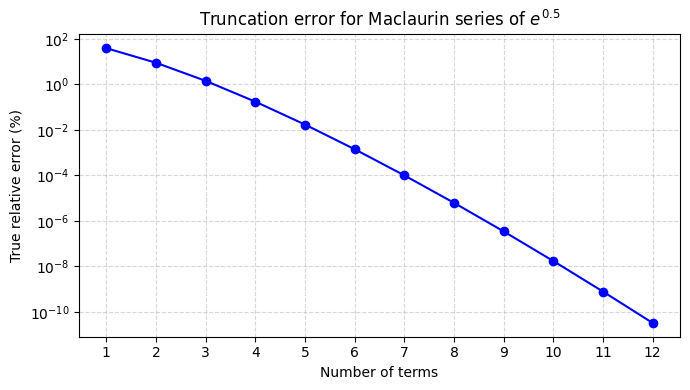

In [10]:
x = 0.5
f_true = np.exp(x)
max_terms = 12

n_terms = np.arange(1, max_terms + 1)
errors  = np.zeros(max_terms)
sol = 0.0
for k in range(max_terms):
    sol += x**k / math.factorial(k)
    errors[k] = abs(f_true - sol) / f_true * 100

plt.figure(figsize=(7, 4))
plt.semilogy(n_terms, errors, 'bo-', markersize=6)
plt.xlabel('Number of terms')
plt.ylabel('True relative error (%)')
plt.title(r'Truncation error for Maclaurin series of $e^{0.5}$')
plt.xticks(n_terms)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()

---
## 3. Roundoff Error & Floating-Point Arithmetic

### 3.1 IEEE 754 Double Precision

All modern computers store real numbers as **double-precision floating-point** (64 bits):

```
┌─┬──────────┬──────────────────────────────────────────────────────┐
│S│ Exponent │                    Mantissa (52 bits)                 │
│1│  11 bits │                                                       │
└─┴──────────┴──────────────────────────────────────────────────────┘
```

Any number is stored as $\pm m \times 2^e$ where $m$ is the **normalised mantissa** (52 bits → ~15–17 significant decimal digits) and $e$ is the exponent.

### 3.2 Machine Epsilon

**Machine epsilon** $\varepsilon_{\text{mach}}$ is the smallest number such that
$$\text{fl}(1 + \varepsilon_{\text{mach}}) > 1$$

It is the precision limit: any relative error smaller than $\varepsilon_{\text{mach}}$ is invisible to the computer.

In [11]:
# Floating-point properties of Python's default float (IEEE 754 double)
fi = np.finfo(float)
print(f'Machine epsilon : {fi.eps:.6e}')
print(f'Largest float   : {fi.max:.6e}')
print(f'Smallest float  : {fi.tiny:.6e}')   # smallest positive normalised
print(f'Significant digs: {fi.precision}')

Machine epsilon : 2.220446e-16
Largest float   : 1.797693e+308
Smallest float  : 2.225074e-308
Significant digs: 15


In [12]:
# Verify: 1 + eps/2 == 1  (below machine epsilon → invisible)
eps = np.finfo(float).eps
print(f'1 + eps     = {1 + eps}')       # distinguishable from 1
print(f'1 + eps/2   = {1 + eps/2}')     # rounds back to exactly 1
print(f'1 + eps/2 == 1: {1 + eps/2 == 1}')

1 + eps     = 1.0000000000000002
1 + eps/2   = 1.0
1 + eps/2 == 1: True


### 3.3 Binary Representation of Decimal Fractions

Most decimal fractions (e.g. 0.1) cannot be represented **exactly** in binary, just as 1/3 cannot be represented exactly in decimal. The computer stores the nearest representable value, introducing a small but nonzero roundoff error.

In [13]:
# 0.1 is not exactly representable in binary floating point!
print(f'0.1 (default display) : {0.1}')
print(f'0.1 (20 decimal places): {0.1:.20f}')
print(f'0.1 + 0.2             : {0.1 + 0.2:.20f}')
print(f'0.1 + 0.2 == 0.3      : {0.1 + 0.2 == 0.3}')
print(f'0.3 (20 decimal places): {0.3:.20f}')

0.1 (default display) : 0.1
0.1 (20 decimal places): 0.10000000000000000555
0.1 + 0.2             : 0.30000000000000004441
0.1 + 0.2 == 0.3      : False
0.3 (20 decimal places): 0.29999999999999998890


In [14]:
def decimal_to_binary(num, k_prec=20):
    """Convert a positive decimal number to its binary representation."""
    integral   = int(num)
    fractional = num - integral
    int_bits   = bin(integral).replace('0b', '') if integral else '0'
    frac_bits  = ''
    for _ in range(k_prec):
        fractional *= 2
        bit = int(fractional)
        frac_bits += str(bit)
        fractional -= bit
    return f'{int_bits}.{frac_bits}'

for val in [0.5, 0.25, 0.1, 0.3]:
    print(f'{val} → {decimal_to_binary(val)}')

0.5 → 0.10000000000000000000
0.25 → 0.01000000000000000000
0.1 → 0.00011001100110011001
0.3 → 0.01001100110011001100


> **Observe:** 0.5 = 0.1 and 0.25 = 0.01 in binary — exact. But 0.1 and 0.3 produce non-terminating binary patterns, just like 1/3 = 0.333… in decimal.

### 3.4 Accumulation of Roundoff

Small individual rounding errors can accumulate significantly when an operation is repeated many times.

In [15]:
# Adding 0.0001 exactly 10 000 times should give 1.0
def repeated_sum(increment, reps):
    s = 0.0
    for _ in range(reps):
        s += increment
    return s

result = repeated_sum(0.0001, 10_000)
print(f'Sum of 0.0001 × 10 000 = {result:.16f}')
print(f'Expected               = 1.0000000000000000')
print(f'Roundoff error         = {abs(result - 1.0):.2e}')

Sum of 0.0001 × 10 000 = 0.9999999999999062
Expected               = 1.0000000000000000
Roundoff error         = 9.38e-14


In [37]:
# Kahan Summation Algorithm
def kahan_sum(values):
    total = 0.0           # sum
    c = 0.0           # compensation term
    for v in values:
        y = v - c      # adjustment
        t = total + y       # actual sum
        c = (t - total) - y   # capture error
        total = t
    return total

import numpy as np

vals = [0.0001] * 10_000 # list 

naive  = sum(vals)
kahan  = kahan_sum(vals)
ref    = np.sum(vals)   # numpy uses pairwise summation internally

print(f'Naive  : {naive:.16f}   err = {abs(naive - 1):.2e}')
print(f'Kahan  : {kahan:.16f}   err = {abs(kahan - 1):.2e}')
print(f'NumPy  : {ref:.16f}   err = {abs(ref   - 1):.2e}')


Naive  : 0.9999999999999062   err = 9.38e-14
Kahan  : 1.0000000000000000   err = 0.00e+00
NumPy  : 1.0000000000000002   err = 2.22e-16


### 3.5 Catastrophic Cancellation

When two nearly equal numbers are subtracted, the significant digits cancel and the result is dominated by roundoff. This is called **catastrophic (or subtractive) cancellation**.

**Example:** The quadratic formula $x = \dfrac{-b \pm \sqrt{b^2 - 4ac}}{2a}$

When $b^2 \gg 4ac$, one root involves subtracting two nearly equal large numbers.

In [38]:
# Equation: x^2 - 100000.0001 x + 1 = 0
# Roots: x1 ≈ 100000.0001, x2 ≈ 0.000010000
a, b, c = 1, -100000.0001, 1

discriminant = math.sqrt(b**2 - 4*a*c)

# Standard quadratic formula
x1_std = (-b + discriminant) / (2*a)
x2_std = (-b - discriminant) / (2*a)    # cancellation occurs here!

# Numerically stable form: use x2 = c / (a * x1)
x2_stable = c / (a * x1_std)

# True roots (high precision)
x1_true = 100000.00000999990
x2_true = 0.000010000000100000

print(f'Standard   x1 = {x1_std:.10f}   error = {abs(x1_std - x1_true):.2e}')
print(f'Standard   x2 = {x2_std:.10f}   error = {abs(x2_std - x2_true):.2e}')
print(f'Stable     x2 = {x2_stable:.10f}   error = {abs(x2_stable - x2_true):.2e}')

Standard   x1 = 100000.0000900000   error = 8.00e-05
Standard   x2 = 0.0000100000   error = 3.99e-12
Stable     x2 = 0.0000100000   error = 1.09e-13


<!-- x1_s = (-b_ + disc) / (2*a_) -->
<!-- x2_stab = c / (a * x1_s) -->

In [ ]:
# --- Exercise ---
# Investigate how the error in x2_std changes as |b| grows.
# For each value of b below, compute both roots and the relative error in x2.

print(f'{"b":>12}  {"x2 standard":>16}  {"x2 stable":>16}  {"rel err std (%)":>17}  {"rel err stable (%)":>20}')
print('-' * 90)

for b_val in [1e2, 1e4, 1e6, 1e8, 1e10]:
    a_, b_, c_ = 1, -b_val, 1
    disc = math.sqrt(b_**2 - 4*a_*c_)
    # --- COMPLETE: compute x2_std and x2_stable ---
    x1_s = 
    x2_s = (-b_ - disc) / (2*a_)  # standard formula
    x2_stab =   # stable formula: c / (a * x1)
    # --- COMPLETE ---
    x2_ref = 1.0 / x1_s             # reference (stable)
    err_std  = abs(x2_s    - x2_ref) / abs(x2_ref) * 100
    err_stab = abs(x2_stab - x2_ref) / abs(x2_ref) * 100
    print(f'{b_val:>12.0e}  {x2_s:>16.10f}  {x2_stab:>16.10f}  {err_std:>17.6e}  {err_stab:>20.6e}')

           b       x2 standard         x2 stable    rel err std (%)    rel err stable (%)
------------------------------------------------------------------------------------------
       1e+02      0.0100010002      0.0100010002       1.221123e-11          0.000000e+00
       1e+04      0.0001000000      0.0001000000       1.117663e-07          0.000000e+00
       1e+06      0.0000010000      0.0000010000       7.614492e-04          0.000000e+00
       1e+08      0.0000000075      0.0000000100       2.549419e+01          0.000000e+00
       1e+10      0.0000000000      0.0000000001       1.000000e+02          0.000000e+00


<!-- SOLUTION
x2_s    = (-b_ - disc) / (2*a_)
x2_stab = c_ / (a_ * x1_s)
-->

> **Key insight:** As $|b|$ grows, the standard formula for $x_2$ loses precision dramatically (relative error approaches 100%), while the stable reformulation keeps the error near machine epsilon.

---
## 4. Finite Differences & Combined Error Analysis

### 4.1 Numerical Differentiation via Finite Differences

Starting from the Taylor expansion $f(x + h) = f(x) + f'(x)h + \frac{f''(x)}{2!}h^2 + \cdots$, we can isolate $f'(x)$:

| Approximation | Formula | Error order |
|---------------|---------|-------------|
| **Forward difference** | $f'(x) \approx \dfrac{f(x+h)-f(x)}{h}$ | $O(h)$ |
| **Backward difference** | $f'(x) \approx \dfrac{f(x)-f(x-h)}{h}$ | $O(h)$ |
| **Central difference** | $f'(x) \approx \dfrac{f(x+h)-f(x-h)}{2h}$ | $O(h^2)$ |

The central difference cancels the $O(h)$ term, giving **second-order accuracy** — a free improvement from symmetry.

### 4.2 Derivation of Central Difference

$$f(x+h) = f(x) + f'(x)h + \frac{f''(x)}{2}h^2 + \frac{f'''(x)}{6}h^3 + \cdots$$
$$f(x-h) = f(x) - f'(x)h + \frac{f''(x)}{2}h^2 - \frac{f'''(x)}{6}h^3 + \cdots$$

Subtracting: $f(x+h) - f(x-h) = 2f'(x)h + \frac{f'''(x)}{3}h^3 + \cdots$

Solving for $f'(x)$:
$$f'(x) = \frac{f(x+h)-f(x-h)}{2h} - \frac{f'''(x)}{6}h^2 + \cdots = \frac{f(x+h)-f(x-h)}{2h} + O(h^2)$$

### 4.3 Example: Differentiating $f(x) = -0.1x^4 - 0.15x^3 - 0.5x^2 - 0.25x + 1.2$

Analytical derivative: $f'(x) = -0.4x^3 - 0.45x^2 - x - 0.25$

In [40]:
f     = lambda x: -0.1*x**4 - 0.15*x**3 - 0.5*x**2 - 0.25*x + 1.2
dfdx  = lambda x: -0.4*x**3 - 0.45*x**2 -       x - 0.25

x  = 0.5
h  = 0.5

fm = f(x - h)   # f(x-h)
fi = f(x)       # f(x)
fp = f(x + h)   # f(x+h)

print(f'f(x-h) = {fm:8.4f}')
print(f'f(x)   = {fi:8.4f}')
print(f'f(x+h) = {fp:8.4f}')
print(f"True f'(x) = {dfdx(x):8.4f}")

f(x-h) =   1.2000
f(x)   =   0.9250
f(x+h) =   0.2000
True f'(x) =  -0.9125


<!-- dfdx_forward  =                #(fp - fi) / h
dfdx_backward =                #(fi - fm) / h
dfdx_central  =                #(fp - fm) / (2*h) -->

In [43]:
# --- COMPLETE: fill in the three finite difference formulas ---
dfdx_forward  =                 
dfdx_backward =                 
dfdx_central  =                 
# --- COMPLETE ---

true_val = dfdx(x)
et_fwd = abs(true_val - dfdx_forward)  / abs(true_val) * 100
et_bwd = abs(true_val - dfdx_backward) / abs(true_val) * 100
et_cen = abs(true_val - dfdx_central)  / abs(true_val) * 100

print(f'{"Method":>12}  {"Estimate":>10}  {"True Rel Err (%)":>18}')
print('-' * 45)
print(f'{"Forward":>12}  {dfdx_forward:>10.5f}  {et_fwd:>18.4f}')
print(f'{"Backward":>12}  {dfdx_backward:>10.5f}  {et_bwd:>18.4f}')
print(f'{"Central":>12}  {dfdx_central:>10.5f}  {et_cen:>18.4f}')
print(f'{"True":>12}  {true_val:>10.5f}')

SyntaxError: invalid syntax (1221681453.py, line 2)

<!-- SOLUTION
dfdx_forward  = (fp - fi) / h
dfdx_backward = (fi - fm) / h
dfdx_central  = (fp - fm) / (2*h)
-->

> **Observe:** Central difference gives a much smaller error than forward or backward, even though it uses the same function evaluations at $x \pm h$.

### 4.4 Effect of Step Size: Truncation vs. Roundoff

As $h$ decreases:
- **Truncation error** $\propto h^2$ (for central difference) → decreases ✓
- **Roundoff error** $\propto \varepsilon_{\text{mach}} / h$ → **increases** ✗

There is an optimal step size $h^* \approx \varepsilon_{\text{mach}}^{1/3}$ that minimises total error.

For double precision: $h^* \approx (2.2 \times 10^{-16})^{1/3} \approx 6 \times 10^{-6}$

In [44]:
def step_size_analysis(func, dfunc, x, n_steps=15):
    """
    Compute central-difference derivative for step sizes h = 10^0, 10^-1, ..., 10^{-(n-1)}
    and record the absolute error against the analytical derivative.
    """
    true_val = dfunc(x)
    H = np.zeros(n_steps)
    E = np.zeros(n_steps)

    h = 1.0
    for i in range(n_steps):
        H[i] = h
        approx = (func(x + h) - func(x - h)) / (2 * h)
        E[i]   = abs(true_val - approx)
        h /= 10

    return H, E

H, E = step_size_analysis(f, dfdx, x=0.5)

print(f'{"Step size":>14}  {"Approx deriv":>18}  {"Abs error":>14}')
print('-' * 52)
for i in range(len(H)):
    approx = (f(0.5 + H[i]) - f(0.5 - H[i])) / (2 * H[i])
    print(f'{H[i]:>14.1e}  {approx:>18.14f}  {E[i]:>14.4e}')

     Step size        Approx deriv       Abs error
----------------------------------------------------
       1.0e+00   -1.26250000000000      3.5000e-01
       1.0e-01   -0.91600000000000      3.5000e-03
       1.0e-02   -0.91253500000000      3.5000e-05
       1.0e-03   -0.91250035000001      3.5000e-07
       1.0e-04   -0.91250000349985      3.4998e-09
       1.0e-05   -0.91250000003318      3.3178e-11
       1.0e-06   -0.91250000000542      5.4228e-12
       1.0e-07   -0.91249999945031      5.4969e-10
       1.0e-08   -0.91250000333609      3.3361e-09
       1.0e-09   -0.91250001998944      1.9989e-08
       1.0e-10   -0.91250007550059      7.5501e-08
       1.0e-11   -0.91250340616966      3.4062e-06
       1.0e-12   -0.91249230393942      7.6961e-06
       1.0e-13   -0.91260332624188      1.0333e-04
       1.0e-14   -0.91038288019263      2.1171e-03


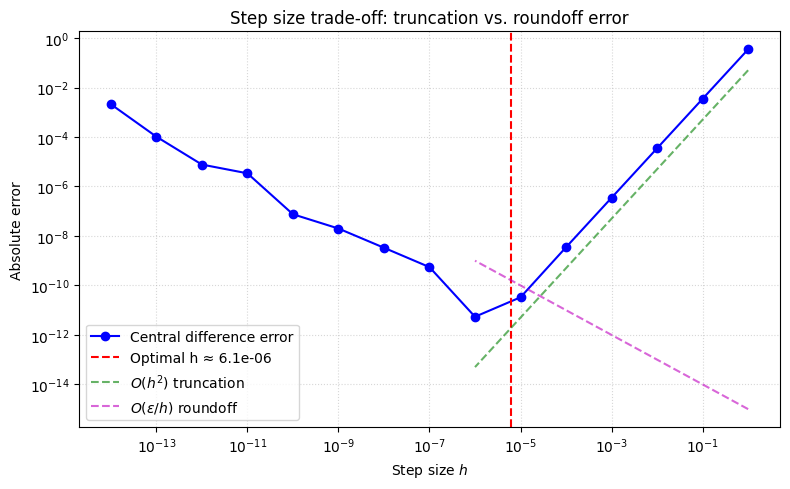

In [45]:
# Visualise the trade-off: truncation error dominates for large h,
# roundoff dominates for small h.

h_opt = np.finfo(float).eps**(1/3)

plt.figure(figsize=(8, 5))
plt.loglog(H, E, 'bo-', markersize=6, label='Central difference error')
plt.axvline(h_opt, color='r', ls='--', label=f'Optimal h ≈ {h_opt:.1e}')

# Reference slopes
h_ref = np.logspace(0, -6, 50)
plt.loglog(h_ref, 0.05 * h_ref**2,  'g--', alpha=0.6, label=r'$O(h^2)$ truncation')
plt.loglog(h_ref, 1e-15 / h_ref,    'm--', alpha=0.6, label=r'$O(\varepsilon/h)$ roundoff')

plt.xlabel('Step size $h$')
plt.ylabel('Absolute error')
plt.title("Step size trade-off: truncation vs. roundoff error")
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()

### 4.5 Exercise: Compare All Three Difference Methods

Repeat the step-size analysis for **forward** and **central** differences and plot both on the same figure to visually confirm that central differences converge as $O(h^2)$ while forward differences converge as $O(h)$.

<!-- E_fwd[i] = abs(true_val - (f(0.5 + h) - f(0.5)) / h)
    E_cen[i] = abs(true_val - (f(0.5 + h) - f(0.5 - h)) / (2*h))>

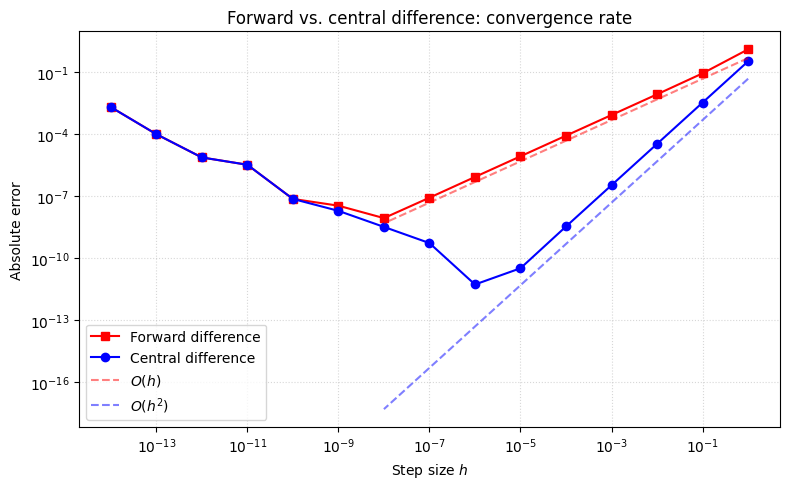

In [ ]:
n_steps = 15
H  = np.zeros(n_steps)
E_fwd = np.zeros(n_steps)
E_cen = np.zeros(n_steps)

true_val = dfdx(0.5)
h = 1.0
for i in range(n_steps):
    H[i] = h
    # - - - - Complete - - - 
    E_fwd[i] =  
    E_cen[i] =  
    # - - - - Complete - - - 
    h /= 10

plt.figure(figsize=(8, 5))
plt.loglog(H, E_fwd, 'rs-', markersize=6, label='Forward difference')
plt.loglog(H, E_cen, 'bo-', markersize=6, label='Central difference')

h_ref = np.logspace(0, -8, 80)
plt.loglog(h_ref, 0.5  * h_ref,    'r--', alpha=0.5, label=r'$O(h)$')
plt.loglog(h_ref, 0.05 * h_ref**2, 'b--', alpha=0.5, label=r'$O(h^2)$')

plt.xlabel('Step size $h$')
plt.ylabel('Absolute error')
plt.title('Forward vs. central difference: convergence rate')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()

<!-- SOLUTION
E_fwd[i] = abs(true_val - (f(0.5 + h) - f(0.5)) / h)
E_cen[i] = abs(true_val - (f(0.5 + h) - f(0.5 - h)) / (2*h))
-->

---
## Summary

| Concept | Key Formula / Rule |
|---------|--------------------|
| **True relative error** | $\varepsilon_t = \|E_t\| / \|x_{\text{true}}\| \times 100\%$ |
| **Approximate relative error** | $\varepsilon_a = \|x_{\text{new}} - x_{\text{prev}}\| / \|x_{\text{new}}\| \times 100\%$ |
| **Scarborough criterion** | $\varepsilon_s = 0.5 \times 10^{2-n}$ % for $n$ sig. figs. |
| **Taylor truncation error** | $O(h^{n+1})$ when keeping $n+1$ terms |
| **Machine epsilon** | $\varepsilon_{\text{mach}} \approx 2.22 \times 10^{-16}$ (double) |
| **Binary fractions** | Most decimal fractions are inexact in binary |
| **Catastrophic cancellation** | Subtraction of nearly equal numbers kills precision |
| **Forward / Backward difference** | $O(h)$ truncation error |
| **Central difference** | $O(h^2)$ truncation error — always prefer this |
| **Optimal step size** | $h^* \approx \varepsilon_{\text{mach}}^{1/3} \approx 10^{-5}$ |

